# Only GSCs can intiate and sustain a tumor

CSCs are defined functionally via there ability to intiate tumors (in xenotransplantation epxeriments).
Progenitor / non-stem cells on the other hand have finite replicative potential and so therefore cannot initate a tumor.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import gsc_model_functions as gmf

In [2]:
# params for model simulation
dt = 0.1
t_end = 100
n = 10 # for 3 out of 4 assume 10 compartments
n2 = 4 # for one of them consider only 4 
r = np.zeros(n)
r[0] = 1
Ps = 0.52
k = 1
ms = 0.2
mv = np.ones(n)*0.4
mv[-1] = 0
delta_s = 0.001
delta_v = np.ones(n)*0.05

# Consider 4 different ICs
small_IC = 0.0001
big_IC = 0.1

# Small number of GSCs only (tumour initatiing)
u0 = np.zeros(n+1)
u0[0] = small_IC

# Small number of PCs only (non - initating)
u0_1 = np.zeros(n+1)
u0_1[1] = small_IC

# Large number of PC can transiently sustain a tumour
u0_2 = np.zeros(n+1)
u0_2[1] = big_IC

# Large number of PCs but only 5 proliferative capacity
u0_3 = np.zeros(n2+1)
u0_3[1] = big_IC

t,u = gmf.simulate_simple(t_end,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r)
t,u1 = gmf.simulate_simple(t_end,dt,u0_1,n,Ps,k,ms,mv,delta_s,delta_v,r)
t,u2 = gmf.simulate_simple(t_end,dt,u0_2,n,Ps,k,ms,mv,delta_s,delta_v,r)
t,u3 = gmf.simulate_simple(t_end,dt,u0_3,n2,Ps,k,ms,mv,delta_s,delta_v,r)

In [3]:
# Colors from red to green
cmap = plt.get_cmap('RdYlGn')
# Interpolated colors at these positions
col = [cmap(p) for p in np.linspace(0, 1, 11)]


def plot_all_compartments(u,ax, t = t):
    for i in range(len(u[1,:])):
        ax.plot(t,u[:,i], color  = col[i])
    
    ax.plot(t,np.sum(u, axis=1), color = 'k')

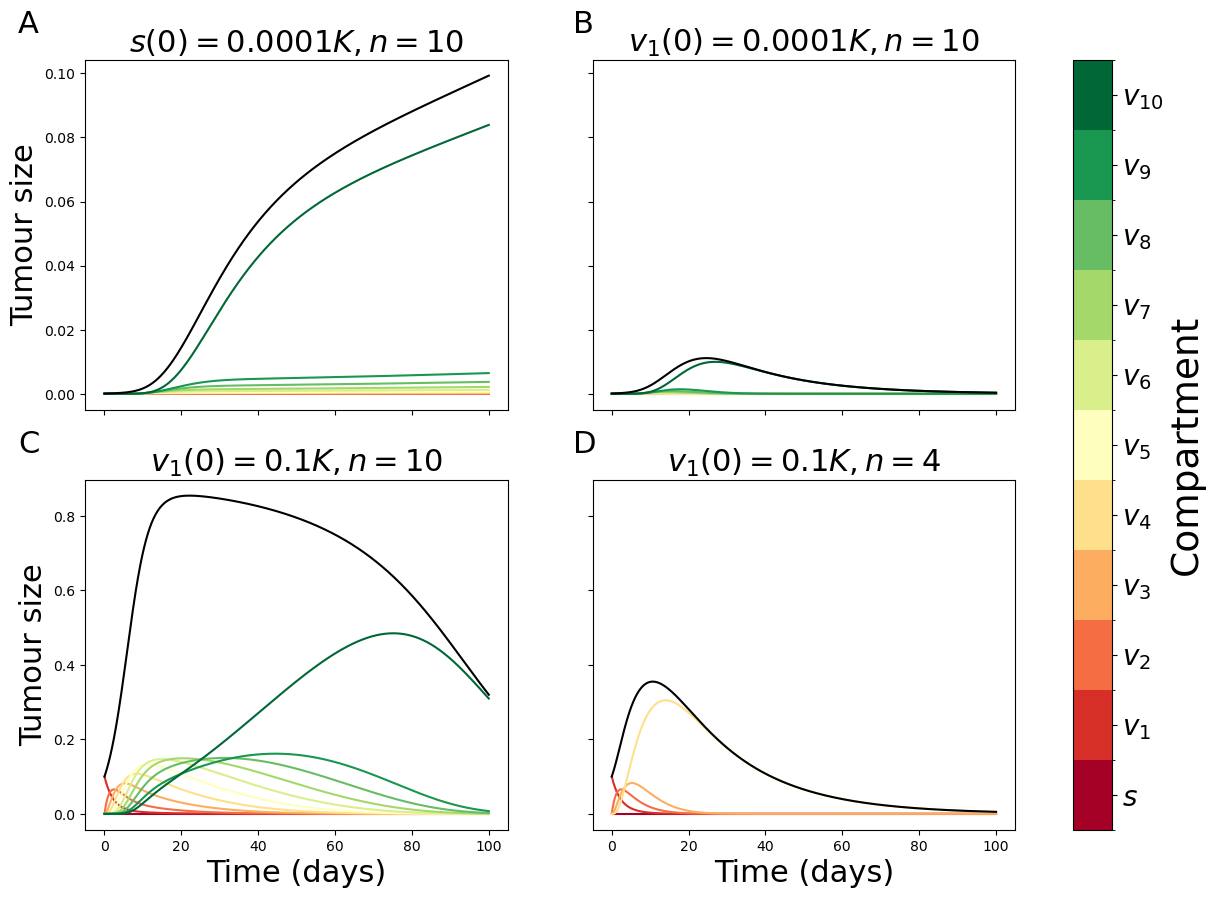

In [4]:
fs = 22
ts = 20

fig, ax = plt.subplots(2,2, figsize = (15, 10), sharey='row', sharex=True)


plot_all_compartments(u,ax[0,0])
plot_all_compartments(u1,ax[0,1])
plot_all_compartments(u2, ax[1,0])
plot_all_compartments(u3, ax[1,1])

ax[0,0].set_title(f"$s(0)={small_IC}K, n = {n}$",fontsize = fs)
ax[0,1].set_title(f"$v_1(0)={small_IC}K, n = {n}$", fontsize = fs)
ax[1,0].set_title(f"$v_1(0)={big_IC}K, n={n}$", fontsize = fs)
ax[1,1].set_title(f"$v_1(0)={big_IC}K, n={n2}$", fontsize = fs)
ax[1,1].set_xlabel("Time (days)", fontsize = fs)
ax[1,0].set_xlabel("Time (days)", fontsize = fs)
ax[0,0].set_ylabel("Tumour size", fontsize = fs)
ax[1,0].set_ylabel("Tumour size", fontsize = fs)

# Create discrete colormap and colorbar
cmap_discrete = ListedColormap(col)
bounds = np.arange(0, 12)  # 0 to 11 compartments
norm = BoundaryNorm(bounds, cmap_discrete.N)


cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap_discrete),
    ticks=np.arange(0.5, 11.5),  # center ticks
    ax = ax.ravel().tolist(),
    orientation='vertical',
    label='Compartment index'
)

c_lab = ["$s$"] + [f"$v_{{{i}}}$" for i in range(1, 11)]
cbar.ax.set_yticklabels(c_lab, fontsize = ts)  # label as 1..11

cbar.set_label('Compartment', fontsize=fs+5)  


# Subplot labels outside the plots
labels = ['A', 'B', 'C', 'D']

# Coordinates in figure fraction (0,0=bottom-left, 1,1=top-right)
fig.text(0.08, 0.93, labels[0], fontsize=fs, va='top', ha='left')
fig.text(0.45, 0.93, labels[1], fontsize=fs,  va='top', ha='left')
fig.text(0.08, 0.51, labels[2], fontsize=fs, va='top', ha='left')
fig.text(0.45, 0.51, labels[3], fontsize=fs,  va='top', ha='left')

# add max attainable size lines
max_10 = big_IC* (2**n)


plt.savefig("Figs/GSC_initiate.pdf", bbox_inches="tight")
plt.show()

Thesis examinsers wanted the axis limited changed.

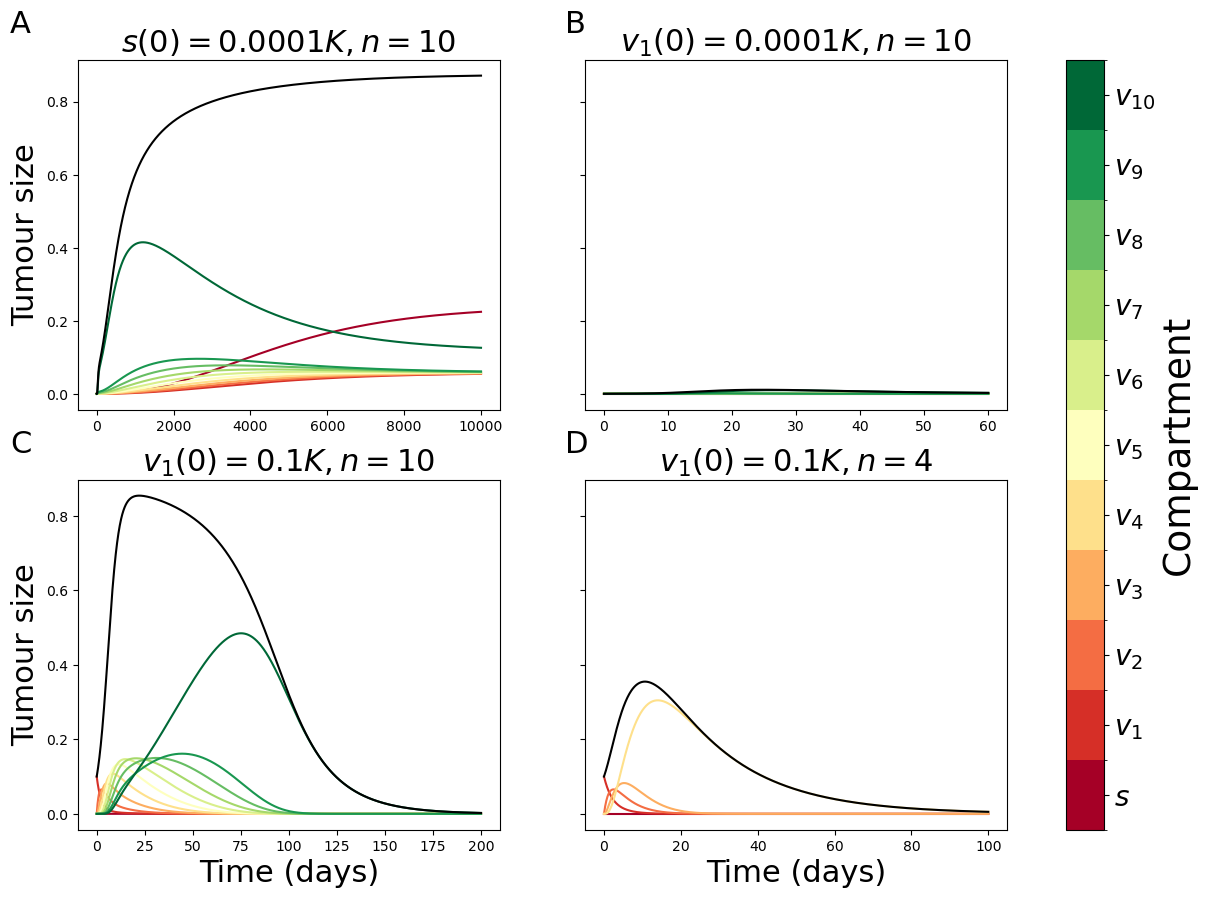

In [5]:
t_endA = 10000
t_endB = 60
t_endC = 200
t_endD = 100
t1,u = gmf.simulate_simple(t_endA,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r)
t2,u1 = gmf.simulate_simple(t_endB,dt,u0_1,n,Ps,k,ms,mv,delta_s,delta_v,r)
t3,u2 = gmf.simulate_simple(t_endC,dt,u0_2,n,Ps,k,ms,mv,delta_s,delta_v,r)
t4,u3 = gmf.simulate_simple(t_endD,dt,u0_3,n2,Ps,k,ms,mv,delta_s,delta_v,r)

fs = 22
ts = 20

fig, ax = plt.subplots(2,2, figsize = (15, 10), sharey='row')


plot_all_compartments(u,ax[0,0], t =t1)
plot_all_compartments(u1,ax[0,1], t =t2)
plot_all_compartments(u2, ax[1,0], t =t3)
plot_all_compartments(u3, ax[1,1], t =t4)

ax[0,0].set_title(f"$s(0)={small_IC}K, n = {n}$",fontsize = fs)
ax[0,1].set_title(f"$v_1(0)={small_IC}K, n = {n}$", fontsize = fs)
ax[1,0].set_title(f"$v_1(0)={big_IC}K, n={n}$", fontsize = fs)
ax[1,1].set_title(f"$v_1(0)={big_IC}K, n={n2}$", fontsize = fs)
ax[1,1].set_xlabel("Time (days)", fontsize = fs)
ax[1,0].set_xlabel("Time (days)", fontsize = fs)
ax[0,0].set_ylabel("Tumour size", fontsize = fs)
ax[1,0].set_ylabel("Tumour size", fontsize = fs)

# Create discrete colormap and colorbar
cmap_discrete = ListedColormap(col)
bounds = np.arange(0, 12)  # 0 to 11 compartments
norm = BoundaryNorm(bounds, cmap_discrete.N)


cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap_discrete),
    ticks=np.arange(0.5, 11.5),  # center ticks
    ax = ax.ravel().tolist(),
    orientation='vertical',
    label='Compartment index'
)

c_lab = ["$s$"] + [f"$v_{{{i}}}$" for i in range(1, 11)]
cbar.ax.set_yticklabels(c_lab, fontsize = ts)  # label as 1..11

cbar.set_label('Compartment', fontsize=fs+5)  


# Subplot labels outside the plots
labels = ['A', 'B', 'C', 'D']

# Coordinates in figure fraction (0,0=bottom-left, 1,1=top-right)
fig.text(0.08, 0.93, labels[0], fontsize=fs, va='top', ha='left')
fig.text(0.45, 0.93, labels[1], fontsize=fs,  va='top', ha='left')
fig.text(0.08, 0.51, labels[2], fontsize=fs, va='top', ha='left')
fig.text(0.45, 0.51, labels[3], fontsize=fs,  va='top', ha='left')

# add max attainable size lines
max_10 = big_IC* (2**n)


plt.savefig("Figs/GSC_initiate_updates.pdf", bbox_inches="tight")
plt.show()

In [6]:
# calculate the maximum attainable size for a given initial condition assuming not death and no carrying capcity
def N_max(v_0):
    N_m = 0
    n = len(v_0)
    for i in range(n):
        N_m = N_m + (2**(n - i - 1)) * v_0[i]
    return N_m

# the evolution of V with no carrying capacity or death in PCs
def v_no_K(V, n, mv):

    dVdt = np.zeros(n)
    dVdt[0] = - mv[0]*V[0] 
    
    for i in range(1,n):
        dVdt[i] =  2*mv[i-1]*V[i-1] - mv[i]*V[i]

    return dVdt


In [7]:
t = np.linspace(0, 100, 100)
dt = t[1] - t[0]
n = 10 # number of PC compartments 
mv = np.ones(n)* 0.4
mv[-1] = 0
V = np.zeros((len(t),n))
V[0,0] = 100

for i in range(len(t)-1):
    V[i+1,:] = V[i,:] + dt * v_no_K(V[i,:], n, mv)
    #print(v_no_K(V[i,:], n, mv))

N_m = N_max(V[0,:])
N = np.sum(V, axis =1)


# simulate  full model
K = 1000000
IC = np.zeros(n+1)
IC[1] = 100
delta_V = np.ones(n)*0.01

_, u_V = gmf.simulate_simple(t[-1],dt,IC,n,Ps,K,ms,mv,delta_s,delta_V,r)
N_uV = np.sum(u_V, axis = 1)

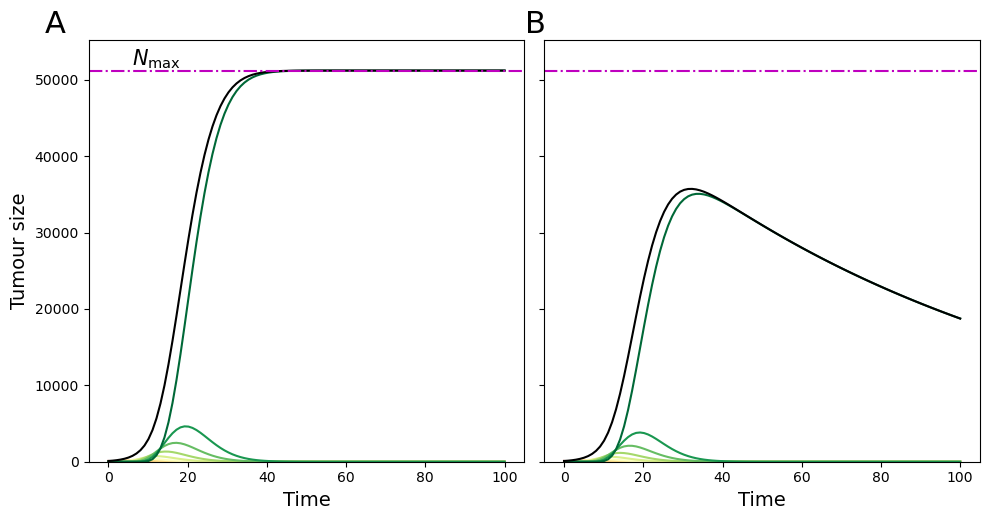

In [8]:
fig, ax = plt.subplots(1,2, figsize = (10,5), sharey=True)
for i in range(len(V[1,:])):
    ax[0].plot(t,V[:,i], color  = col[i+1])
    ax[1].plot(t,u_V[:,i+1], color  = col[i+1])

ax[0].plot(t, N, 'k-')
ax[1].plot(t, N_uV, 'k-')
ax[0].axhline(N_m, color = 'm', linestyle = '-.')
ax[1].axhline(N_m, color = 'm', linestyle = '-.')
ax[0].set_xlabel("Time", fontsize = 14)
ax[1].set_xlabel("Time", fontsize = 14)
ax[0].set_ylabel("Tumour size", fontsize = 14)
ax[0].text(x = 0.1, y = 0.94, s = "$N_\\text{max}$", transform = ax[0].transAxes, fontsize = 15)
ax[0].set_ylim([0, N_m+4000])



fig.text(0.05, 1.03, 'A', fontsize=fs, va='top', ha='left')
fig.text(0.53, 1.03, 'B', fontsize=fs, va='top', ha='left')

plt.tight_layout()

plt.savefig("Figs/PC_max_size.pdf", bbox_inches="tight")
plt.show()

In [9]:
N_m*2

102400.0